In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install optuna
!pip install flowio

In [ ]:
import shutil
import pandas as pd
import random
import copy
import numpy as np # Import numpy for checking finite values
import matplotlib.pyplot as plt # Import matplotlib for potential debugging
import os
import math

PYTHONHASHSEED = '42'
TF_DETERMINISTIC_OPS = '1'
TF_CUDNN_DETERMINISTIC = '1'
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # For CuDNN ops

import glob
import json
import tensorflow as tf
import sys
from itertools import zip_longest
import pickle
import time
import csv
import optuna
from optuna.samplers import TPESampler # Added this line
import traceback
import gc

from sklearn import metrics
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

In [ ]:

fixed_path = '/content/drive/MyDrive/0.Master_Thesis/'

if fixed_path not in sys.path:
    sys.path.append(fixed_path)

cellcnn_path = f'{fixed_path}CellCNN/'
if cellcnn_path not in sys.path:
    sys.path.append(cellcnn_path)

model_path = f'{cellcnn_path}Old_CellCNN/'
if model_path not in sys.path:
    sys.path.append(model_path)

save_path = f'{cellcnn_path}results/'
if save_path not in sys.path:
    sys.path.append(save_path)

modules_dir = f'{cellcnn_path}modules/'
if modules_dir not in sys.path:
    sys.path.append(modules_dir)

In [ ]:
decache_files = ['timepoints_elaboration', 'run_models', 'new_datasets_generation',
                'training', 'utils', 'cv_folds', 'classification', 'show_results']

# Remove from cache
from utils import remove_from_cache
remove_from_cache(decache_files)

from model_grid import CellCnn

from timepoints_elaboration import load_data, donation_extraction
from run_models import  trials_train_CellCNN_old, trials_test_CellCNN_old
from new_datasets_generation import splitting_and_dataset_elaboration

from training import run_training, val_res_pred, train_val_finalizing, test_res_pred, find_theta_best
from utils import flatten, remove_labels, retrieve_labels, show_blast_distribution_perc
from utils import prepare_results_to_save, subset_sampling, generate_seeds
from utils import nsub_ncells_comb, save_models, load_models
from cv_folds import generate_LOPOCV_dicts, generate_LOPOCV_folds, extract_fold_features
from classification import find_robust_threshold
from show_results import elaborate_predictions

timepoints_elaboration rimosso dalla cache
model_grid non trovato nella cache
cellcnn_utils non trovato nella cache
downsample non trovato nella cache
timepoints_elaboration non trovato nella cache
results_elaboration non trovato nella cache
run_models non trovato nella cache
new_datasets_generation non trovato nella cache
training non trovato nella cache
utils non trovato nella cache
cv_folds non trovato nella cache
classification non trovato nella cache


# code

In [ ]:
Tuning = False
Training = True

tuning_exp = 'Trial_5_fix_code_NO_AS_bayesian_tuning' ###

starting_seed =  1000
n_sub = 3                                  # n_{subs}
n_cells = 100000                           # n_{cells}
blast_perc = [0.0001, 0.001, 0.01]         # u
nfilter = [5, 7, 9]                        # \mathcal{F}
maxpool_p = [0.01, 1, 10, 100]
learning_r = [0.001, 0.005]                # \eta
grid = False
labels = False
hyper = (nfilter, maxpool_p, learning_r)

blocks = 14
nsub_step = 50
max_ncells = 700
ncells_step = 100

tuning_epochs = 1                          # E
tuning_nruns = 3
bayesian_comb = 2                          # n_{\theta}

n_res = 50                                 # n_{res}
n_cells_res = 100000

config = {}
config['PYTHONHASHSEED'] = PYTHONHASHSEED
config['TF_DETERMINISTIC_OPS'] = TF_DETERMINISTIC_OPS
config['TF_CUDNN_DETERMINISTIC'] = TF_CUDNN_DETERMINISTIC
config['starting_seed'] = starting_seed
config['n_sub '] = n_sub  # check space
config['n_cells'] = n_cells
config['blast_perc'] = blast_perc
config['nfilter'] = nfilter
config['maxpool_p'] = maxpool_p
config['learning_r'] = learning_r
config['grid'] = grid
config['labels'] = labels

config['blocks'] = blocks
config['nsub_step'] = nsub_step
config['max_ncells'] = max_ncells
config['ncells_step'] = ncells_step

config['tuning_epochs'] = tuning_epochs
config['tuning_nruns'] = tuning_nruns
config['bayesian_comb'] = bayesian_comb



config_save_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/'
os.makedirs(config_save_dir, exist_ok=True)

with open(os.path.join(config_save_dir, 'config.pkl'), 'wb') as f:
            pickle.dump(config, f)


In [ ]:
%%time

# Trova tutti i file con estensione specifica in una cartella
data_folder = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'  # cambia con l'estensione che ti serve

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)#, remove_control = True)



0.09
Elaborating file 0: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D15_2.csv
0.0
Elaborating file 1: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D78.csv
0.16
Elaborating file 2: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
0.01
Elaborating file 3: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
0.0
Elaborating file 4: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
0.15
Elaborating file 5: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
0.0
Elaborating file 6: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
39.56
Elaborating file 7: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE2_D15_2.csv
15.06
E

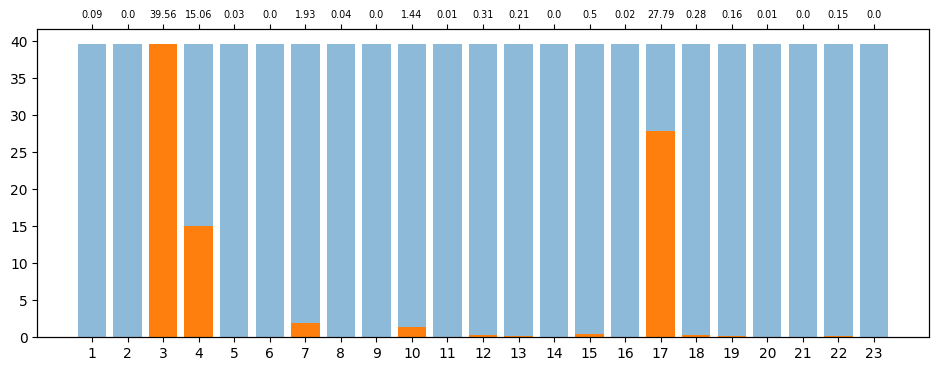

[np.float64(0.09), np.float64(0.0), np.float64(39.56), np.float64(15.06), np.float64(0.03), np.float64(0.0), np.float64(1.93), np.float64(0.04), np.float64(0.0), np.float64(1.44), np.float64(0.01), np.float64(0.31), np.float64(0.21), np.float64(0.0), np.float64(0.5), np.float64(0.02), np.float64(27.79), np.float64(0.28), np.float64(0.16), np.float64(0.01), np.float64(0.0), np.float64(0.15), np.float64(0.0)]


In [ ]:

tot_perc_list = show_blast_distribution_perc(ALL_DATASETS, multiple_donations, return_perc = True, log = False)
print(tot_perc_list)

In [ ]:

full_LOPOCV_dicts = generate_LOPOCV_dicts(multiple_donations, ALL_DATASETS)
LOPOCV_patients_folds = generate_LOPOCV_folds(full_LOPOCV_dicts, ALL_DATASETS, starting_seed)

dict_keys(['2', '3', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['1']) [np.float64(0.08762), np.float64(0.0)]
dict_keys(['1', '3', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['2']) [np.float64(39.55814), np.float64(15.0633)]
dict_keys(['1', '2', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['3']) [np.float64(0.03462), np.float64(0.0)]
dict_keys(['1', '2', '3', '6', '7', '8', '9', '11', '12']) dict_keys(['4']) [np.float64(1.92897), np.float64(0.04035), np.float64(0.0)]
dict_keys(['1', '2', '3', '4', '7', '8', '9', '11', '12']) dict_keys(['6']) [np.float64(1.43503), np.float64(0.00775)]
dict_keys(['1', '2', '3', '4', '6', '8', '9', '11', '12']) dict_keys(['7']) [np.float64(0.31479), np.float64(0.20732), np.float64(0.0)]
dict_keys(['1', '2', '3', '4', '6', '7', '9', '11', '12']) dict_keys(['8']) [np.float64(0.49896), np.float64(0.01692)]
dict_keys(['1', '2', '3', '4', '6', '7', '8', '11', '12']) dict_keys(['9']) [np.float64(27.7918), np.float64(0.2798)]
dict_keys(['1', '2', '

# ncells and nsub bayesian tuning

In [ ]:
%%time

colab = True
start_lopocv_fold = 0
end_lopocv_fold = 0

tuning_exp = 'Trial_5_fix_code_NO_AS_bayesian_tuning' ###


grid = False
starting_seed = starting_seed

weights_outdir = f'{config_save_dir}/weights'
os.makedirs(weights_outdir, exist_ok=True)


# define all possible \theta configurations
all_nsub_ncells_comb = nsub_ncells_comb(ncells_step, max_ncells, blocks, nsub_step)
print(f'Number of Possible combinations: {len(all_nsub_ncells_comb)}')

for LOPOCV_fold_idx, (train_kfolds, test_pat) in enumerate(LOPOCV_patients_folds): # for each LOPO fold

  if LOPOCV_fold_idx >= start_lopocv_fold:
    full_process_time_start = time.time()
    for i in range(1):

        # === load the samples === #
        if LOPOCV_fold_idx != 0:
            multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)

        base_seed = starting_seed + (LOPOCV_fold_idx * 100000)

        print(f'Test patient: {test_pat}')

        # extract train, validation and test patients ids
        fold_features = extract_fold_features(train_kfolds, multiple_donations, tot_perc_list) #Fold feature dictionary creation

        base_seed = starting_seed + (LOPOCV_fold_idx * 100000) + 10000

        for i in range(1):
            print(f'Start Bayesian Search for optimal ncells and nsubs parameters')

            # prepare storing variables
            tested_par = []            #save parameter explored
            best_thresholds = []       # save thresholds
            roc_metrics = []
            val_predicted_for_roc = [] # store predictions from tuning for threshold tuning
            pruned_combinations = []   # save the pruned combination for further analysis
            bayesian_f1_scores = []

            sampler_seed = base_seed
            base_seed += 10
            print(f"LOPO fold {LOPOCV_fold_idx}: Optuna sampler seed = {sampler_seed}")

            # Create the study outside the inner CV loop

            sampler = TPESampler(seed = sampler_seed)
            study = optuna.create_study(direction="maximize", sampler = sampler) # direction="maximize"because we want to maximize the f1-score

            print(f"Start Bayesian optimization on {len(all_nsub_ncells_comb)} possible combinations...")

            benchmark_list = []
            bayesian_comb = bayesian_comb # 15 ### 20   # number of combination to explore

            for i in range(bayesian_comb):
                ncell_start = time.time()

                trial = study.ask() # Ask parameters
                comb_index = trial.suggest_int("combo_idx", 0, len(all_nsub_ncells_comb) - 1) # decide index of the new combination to explore

                ncells, nsubs = all_nsub_ncells_comb[comb_index] # retrieve ncells and nsubs
                tested_par.append((ncells, nsubs))

                print(f'Model {i+1}. Testing params -> ncells: {ncells}, nsubs: {nsubs}')
                print(f'5 Fold CV started')

                tuning_predictions_folds = []
                tuning_results_folds = []
                val_predicted_for_roc_folds = []
                f1_across_folds = []
                is_pruned = False  # pruning flag

                for fold_idx, (train_features, val_features) in fold_features.items():
                    print(f'\nFold: {fold_idx}\n')
                    fold_start = time.time()

                    train_donors_idx, val_donors_idx = train_features[0], val_features[0] # retrieve patients form fold features dictionary

                    # extraxt samples using pre-slitted indexes
                    train_datasets_extracted = donation_extraction(train_donors_idx, multiple_donations, ALL_DATASETS)
                    val_datasets_extracted = donation_extraction(val_donors_idx, multiple_donations, ALL_DATASETS)

                    fold_start = time.time()
                    original_train_datasets, original_train_y = retrieve_labels(train_datasets_extracted, remove = True, flat = True)
                    original_val_datasets, original_val_y = retrieve_labels(val_datasets_extracted, remove = True, flat = True)

                    trials = 1 ### 3  number of time the model have to be trained (at each time a different seed is used)

                    train_CV_seed = base_seed + i*1000 + fold_idx*10 + 1
                    seed_list = generate_seeds(len(LOPOCV_patients_folds)*2, seed = train_CV_seed)

                    pred_CV_seed = base_seed + i*1000 + fold_idx*10 + len(fold_features)*10
                    tuning_prediction_seed_list = generate_seeds(trials, seed = pred_CV_seed)
                    print(seed_list)
                    print(tuning_prediction_seed_list)

                    # remove labels (random search without labels is required)
                    train, val = train_val_finalizing(original_train_datasets, original_val_datasets, grid, labels)

                    tuning_results = []

                    try:
                            # === Train Models === #
                            models_lists = trials_train_CellCNN_old(CellCnn,
                                        train, original_train_y,                           # train set and labels
                                        val_datasets = val, val_y = original_val_y,        # val set and labels
                                        trials=trials,                                     # different seeds to perform
                                        n_cell = ncells,                                   # Explored parameter
                                        nsubset = nsubs,                                   # Explored parameter
                                        max_epochs = tuning_epochs,     ### 35
                                        nrun = tuning_nruns,           ### 10
                                        seed_list = seed_list,
                                        hyper=hyper,
                                        grid = grid,
                                        outdir = weights_outdir)

                            #save models
                            for trial_i, model in enumerate(models_lists):
                                save_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/outer_fold_{LOPOCV_fold_idx}/tuning/bayesian/combination_{ncells}_{nsubs}/inner_fold_{fold_idx}/models/seed_{trial_i}'
                                os.makedirs(save_dir, exist_ok=True)
                                save_models(model, save_dir)



                            # === Prediction Approach: CellCNN with tau = 0.5 === #
                            original_val_datasets, original_val_y = retrieve_labels(val_datasets_extracted, remove = True, flat = True)

                            predictions_list, results_list = trials_test_CellCNN_old(models_lists, original_val_datasets, tuning_prediction_seed_list) # Predict

                            # Elaborate results
                            (pred_phenotype_df, accuracy_list,
                            f1_scores_list, recall_score_list, _) = elaborate_predictions(
                                                                            predictions_list, original_val_y,
                                                                            results=True, # show results
                                                                            beta = 1) # if 2 recall weight twice the precision weight

                            f1_across_folds.append(np.mean(f1_scores_list)) # append the average across seeds
                            tuning_results.append(results_list) # hyperparameters results

                            val_predicted_for_roc_folds.append((predictions_list, original_val_y)) # store full prediction

                    except Exception as e:
                            print(f"Training error: {e}")
                            traceback.print_exc()

                    fold_end = time.time()
                    print(f'Fold: {fold_idx}: Time spent for the {(ncells, nsubs)} combination: {(fold_end- fold_start)}')

                    # === Pruning at the third fold === #
                    if fold_idx == 2:
                        mean_3_folds = np.mean(f1_across_folds)  # compute folds f1_score

                        trial.report(mean_3_folds, step=2)  # Always report so the Bayesian Sampler sees the intermediate value

                        # prune after 3 complete 5 fold cv
                        if len(benchmark_list) >= 3 and mean_3_folds < np.median(benchmark_list):
                            print(f"Pruning criteria met at fold 3. Stopping loop, but saving data...")
                            is_pruned = True
                            break             # break the fold loop


                print('Cross Validation Ended! Computing thresholds, and saving results...')


                val_predicted_for_roc.append(val_predicted_for_roc_folds)
                tuning_results_folds.append(tuning_results)

                # === Finalize with Optuna based on the flag === #
                if is_pruned:
                    print('Pruned!')
                    # Tell the study it was pruned, but we still reach this line!
                    study.tell(trial, state=optuna.trial.TrialState.PRUNED)

                    # We raise it here, AFTER we have done all our saving/processing
                    pruned_combinations.append((ncells, nsubs))
                    continue
                else:
                    # Update benchmark only for successful 5-fold runs
                    benchmark_list.append(np.mean(f1_across_folds[:3]))

                    # Tell to Bayesian search the results. Mandatoy to recompute the probability distrbutions
                    study.tell(trial, np.mean(f1_across_folds))

                print(f'Mean F1 Score across folds: {f1_across_folds}')
                print(f'Time Spent for this trial: {time.time() - ncell_start}')

                bayesian_f1_scores.append(f1_across_folds)


            print("Tuning Ended!")

            print(f'Start check the best combination of parameters')
            pruned_par_idx = [tested_par.index(comb) for comb in pruned_combinations]
            print(f'pruned_par_idx: {pruned_par_idx}')


            # === Choice of \theta^* === #

            f1_tested_par = []
            for v, val_predicted_for_roc_folds in enumerate(val_predicted_for_roc):
              if v not in pruned_par_idx:

                f1_across_folds = []
                for pred_list, val_y in val_predicted_for_roc_folds:
                    (_, _, f1_scores_list, _, _ # predicted phenotipes, accuracy list, f1_score list, recall list
                                            ) = elaborate_predictions(
                                                                pred_list, val_y,
                                                                results=False , # if True show results
                                                                beta = 1) # if 2 recall weight twice the precision weight

                    f1_across_folds.append(np.mean(f1_scores_list))
                f1_tested_par.append(np.mean(f1_across_folds))

            chosen_par = find_theta_best(f1_tested_par, tested_par) # deterministic algorithm for \theta
            best_ncells, best_nsub = chosen_par

            # compute and save roc_threshold
            best_idx = tested_par.index(chosen_par)
            val_predicted_for_roc_folds = val_predicted_for_roc[best_idx]

            # === Tune \tau^{(*, BO)}_{ROC} === #

            # rebuild dataset predictions
            predictions_list, new_val_y = [], []
            for pred_list, val_y in val_predicted_for_roc_folds:
                new_val_y += val_y

                for art_s in pred_list[0]:
                    predictions_list += [art_s[1]]
            print(new_val_y)

            fpr, tpr, thresholds = metrics.roc_curve(new_val_y, predictions_list, pos_label=1)# compute ROC curve

            optimal_idx = np.argmax(tpr >= 0.95)  # index of the threshold that has the highest tpr
            roc_threshold = thresholds[optimal_idx]    # extract the threshold

            print(f"Best Threshold for MRD (Recall=100%): {roc_threshold}")

            print(f'best_ncells, best_nsub: {(best_ncells, best_nsub)}')
            print(f'End check the best combination of parameters')


            # save results
            tuning_save_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/outer_fold_{LOPOCV_fold_idx}/tuning/results'
            os.makedirs(tuning_save_dir, exist_ok=True)

            with open(os.path.join(tuning_save_dir, 'tuning_results_folds.pkl'), 'wb') as f: # hyperparameters results
                        pickle.dump(tuning_results_folds, f)

            with open(os.path.join(tuning_save_dir, 'best_ncells.pkl'), 'wb') as f:
                        pickle.dump(best_ncells, f)

            with open(os.path.join(tuning_save_dir, 'best_nsub.pkl'), 'wb') as f:
                        pickle.dump(best_nsub, f)

            with open(os.path.join(tuning_save_dir, 'tested_par.pkl'), 'wb') as f:
                        pickle.dump(tested_par, f)

            with open(os.path.join(tuning_save_dir, 'val_predicted_for_roc.pkl'), 'wb') as f:
                    pickle.dump(val_predicted_for_roc, f) # prediction used to tune the threshold

            with open(os.path.join(tuning_save_dir, 'pruned_combinations.pkl'), 'wb') as f:
                    pickle.dump(pruned_combinations, f) # prediction used to tune the threshold

            with open(os.path.join(tuning_save_dir, 'roc_threshold.pkl'), 'wb') as f:
                    pickle.dump(roc_threshold, f) # save roc threshold


        # === Tune \tau^{(*, BO)}_{RES} === #

        print(f'Start ensamble tuning robust threshold')
        base_seed += 1000

        multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension) # reload the files

        tuning_load_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/outer_fold_{LOPOCV_fold_idx}/tuning/results'

        with open(os.path.join(tuning_load_dir, 'best_ncells.pkl'), 'rb') as f:
                            best_ncells = pickle.load(f)

        with open(os.path.join(tuning_load_dir, 'best_nsub.pkl'), 'rb') as f:
                            best_nsub = pickle.load(f)

        tuning_models_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/outer_fold_{LOPOCV_fold_idx}/tuning/bayesian/combination_{best_ncells}_{best_nsub}/'

        ensemble_mean_probs_per_patient = []
        fold_features = extract_fold_features(train_kfolds, multiple_donations, tot_perc_list) #Fold feature dictionary creation

        for fold_idx, (train_features, val_features) in fold_features.items():
            print(f'Processing Fold: {fold_idx}')

            val_donors_idx = val_features[0] # retrieve patients form fold features dictionary

            # extraxt samples using pre-slitted indexes
            val_datasets_extracted = donation_extraction(val_donors_idx, multiple_donations, ALL_DATASETS)

            model_trials_dir = f'{tuning_models_dir}/inner_fold_{fold_idx}/models/'
            all_trials = os.listdir(model_trials_dir)
            print(f'all_trials: {all_trials}')

            thr_tuning_seed = base_seed + fold_idx*10
            tuning_prediction_seed_list = generate_seeds(len(all_trials), seed = thr_tuning_seed)

            # === Load inner CV trained models === #

            loaded_models_lists = []
            for i, trial in enumerate(all_trials):
                model_dir = f'{model_trials_dir}/seed_{i}'

                with open(os.path.join(model_dir, 'metadata.pkl'), 'rb') as f:
                    meta = pickle.load(f)

                model = load_models(CellCnn, meta)
                loaded_models_lists.append(model)


            per_donor_original_val_datasets, per_donor_original_val_y = retrieve_labels(val_datasets_extracted, remove = False)

            # robust approach
            val_resample_n = n_cells_res ### 100000
            k = n_res ### 50

            # === resampling prediction === #
            (total_pred_lists, # predictions divided by patient -> file -> sampled subsets pred
            val_total_trial_pred_lists,
            mean_probs_per_patient) = val_res_pred(loaded_models_lists, per_donor_original_val_datasets, val_resample_n, k, tuning_prediction_seed_list[0])

            ensemble_mean_probs_per_patient += mean_probs_per_patient

        base_seed += len(fold_features)*100

        """### Threshold ###"""
        tuning_save_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/outer_fold_{LOPOCV_fold_idx}/tuning/results'
        os.makedirs(tuning_save_dir, exist_ok=True)

        robust_threshold, tot_per_tr_f1_scores = find_robust_threshold(ensemble_mean_probs_per_patient, 'f1', closest = True)
        with open(os.path.join(tuning_save_dir, 'robust_threshold.pkl'), 'wb') as f:
                pickle.dump(robust_threshold, f) # prediction used to tune the threshold
        with open(os.path.join(tuning_save_dir, 'tot_per_tr_f1_scores.pkl'), 'wb') as f:
                pickle.dump(tot_per_tr_f1_scores, f) # prediction used to tune the threshold
        with open(os.path.join(tuning_save_dir, 'ensemble_mean_probs_per_patient.pkl'), 'wb') as f:
                pickle.dump(ensemble_mean_probs_per_patient, f) # prediction used to tune the threshold


        no_pickle_val_predicted_for_roc = copy.deepcopy(val_predicted_for_roc)
        for i, par in enumerate(val_predicted_for_roc):

                for j, (trials, val_y) in enumerate(par):
                    no_pickle_val_predicted_for_roc[i][j] = list(no_pickle_val_predicted_for_roc[i][j])

                    for t, trial in enumerate(trials):

                        list_trial = []
                        for p,  pred in enumerate(trial):
                            list_trial.append(pred.tolist())
                        no_pickle_val_predicted_for_roc[i][j][t] = [list_trial]


        threshold_data = {
                'robust_threshold': float(robust_threshold),
                'roc_threshold': float(roc_threshold),
                'best_nsub': int(best_nsub),
                'best_ncells': int(best_ncells),
                'tested_par': tested_par,
                'val_predicted_for_roc': no_pickle_val_predicted_for_roc,
                'pruned_combinations': pruned_combinations,
                'ensemble_mean_probs_per_patient': ensemble_mean_probs_per_patient,
                'tot_per_tr_f1_scores': tot_per_tr_f1_scores

            }
        with open(f'{tuning_load_dir}/threshold_data.json', 'w') as f:
                json.dump(threshold_data, f)

    bayesian_LOPOCV_time = time.time() - full_process_time_start
    print(f'bayesian_LOPOCV_time: {bayesian_LOPOCV_time}')

    #save seeds
    tuning_save_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/outer_fold_{LOPOCV_fold_idx}/'
    os.makedirs(tuning_save_dir, exist_ok=True)

    with open(os.path.join(tuning_save_dir, 'tuning_seed_info.pkl'), 'wb') as f:
        pickle.dump({
            'starting_seed': starting_seed,
            'LOPOCV_fold_idx': LOPOCV_fold_idx,
            'fold_base_seed': starting_seed + (LOPOCV_fold_idx * 100000),
            'final_tuning_base_seed' : base_seed
        }, f)


    with open(os.path.join(tuning_save_dir, 'bayesian_LOPOCV_time.pkl'), 'wb') as f:
                                pickle.dump(bayesian_LOPOCV_time, f)

    if LOPOCV_fold_idx >= end_lopocv_fold:
        break


[I 2026-03-25 21:32:02,347] A new study created in memory with name: no-name-436bda07-27a9-4e60-aa31-2027be31014a


Number of Possible combinations: 91
Test patient: ['1']
Start Bayesian Search for optimal ncells and nsubs parameters
LOPO fold 0: Optuna sampler seed = 11000
Start Bayesian optimization on 91 possible combinations...
Model 1. Testing params -> ncells: 100, nsubs: 450
5 Fold CV started

Fold: 0

[934938 841497 929831 172593 821337 146331 846064 951053 530247 855698
 451035 439793 362396 468094 742426 856631 460683 384864  42578  12082]
[38250]
Labels from Train and Validations Sets have been REMOVED.
Random Search Ready!
Weight initialization 1 started
Seed used: 934938
No labels detected. "labels" variable set to False
Start generating subsets elabortating samples WITHOUT label column
Number of training subsets generated: 11
Number of validation subsets generated: 11

# ============================================= #
Run: 0

Seed: 944938

 Learning Rate: 0.005


 Number of filters: 9


 k% max pooling: 0.01

34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - f1_score: 0.4721 - loss: 0.4838 - v

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

Weight Initialization 1 out of 1 started!
seed: 38250. Type: <class 'numpy.int64'>
seed: 38250. Type: <class 'int'>


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

...

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 337ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step
Done
Trial 1 Done!

Weight Initialization 1 out of 1 started!
seed: 985787. Type: <class 'numpy.int64'>
seed: 985787. Type: <class 'int'>


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 328ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step
Done
Trial 1 Done!

Weight Initialization 1 out of 1 started!
seed: 668742. Type: <class 'numpy.int64'>
seed: 668742. Type: <class 'int'>


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 354ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step
Done
Trial 1 Done!

Chosen threshold: 65. Associated F1_score: 0.9177
bayesian_LOPOCV_time: 4599.000903367996
CPU times: user 1h 14min 21s, sys: 3min 30s, total: 1h 17min 52s
Wall time: 1h 16min 39s
